<a href="https://colab.research.google.com/github/M0hammadMuhsin/Trader-Sentiment-Analysis/blob/main/PrimeTrade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A

Loading the datasets


In [1]:
import pandas as pd
import numpy as np
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

Number of Rows and Columns (rows, cols)

In [2]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


checking for Missing values and Duplicates


In [3]:
sentiment.isnull().sum()
trades.isnull().sum()
sentiment.duplicated().sum()
trades.duplicated().sum()

np.int64(0)

Converting timestamps and aligning the datasets by date

In [4]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [5]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


trades needed to be cleaned

In [6]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")
print(trades.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [7]:
trades['date'] = pd.to_datetime(trades['timestamp'], unit='ms').dt.date

cleaning sentiment too

In [8]:
sentiment.columns = sentiment.columns.str.strip().str.lower()
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [9]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


now merging both datasets for alignment

In [10]:
df = trades.merge(sentiment[['date','classification']],on='date',how='left')

Creating the key metrics

Daily PnL per Trader

In [11]:
daily_pnl = df.groupby(['account','date'])['closed_pnl'].sum().reset_index()

Win Rate (win rate = % of profitable trades)

In [12]:
df['win'] = df['closed_pnl'] > 0
win_rate = (df.groupby('account')['win'].mean().reset_index())
win_rate.rename(columns={'win': 'win_rate'},inplace=True)
win_rate.head()

,account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


Average Trade Size (usd)

In [13]:
avg_trade_size = (df.groupby('account')['size_usd'].mean().reset_index())
avg_trade_size.rename(columns={'size_usd': 'avg_trade_size_usd'}, inplace=True)

In [14]:
print(avg_trade_size)

                                       account  avg_trade_size_usd
0   0x083384f897ee0f19899168e3b1bec365f52a9012        16159.576734
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         1653.226327
2   0x271b280974205ca63b716753467d5a371de622ab         8893.000898
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4          507.626933
4   0x2c229d22b100a7beb69122eed721cee9b24011dd         3138.894782
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891         1729.941104
6   0x39cef799f8b69da1995852eea189df24eb5cae3c         4790.575486
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6         3445.471265
8   0x420ab45e0bd8863569a5efbb9c05d91f40624641         5189.367128
9   0x430f09841d65beb3f27765503d0f850b8bce7713         2397.824753
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85          517.528924
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4         9084.699093
12  0x4f93fead39b70a1824f981a54d4e55b278e9f760        17098.171055
13  0x513b8629fe877bb581bf244e326a047b249c4ff1        34396.58

Leverage Distribution

Leverage is not provided.
The dataset did not contain a leverage column.
Therefore, trade size (USD) and PnL volatility were used as proxies for risk exposure.


Replacing Leverage With Risk Proxies

In [15]:
df['size_usd'].describe()

,size_usd
count,2.112240e+05
mean,5.639451e+03
std,3.657514e+04
min,0.000000e+00
25%,1.937900e+02
50%,5.970450e+02
75%,2.058960e+03
max,3.921431e+06


In [16]:
pnl_volatility = (df.groupby('account')['closed_pnl'].std().reset_index(name='pnl_std'))


In [17]:
df['abs_pnl'] = df['closed_pnl'].abs()
risk_proxy = (df.groupby('account')['abs_pnl'].mean().reset_index(name='avg_abs_pnl'))

Number of Trades per Day

per trader

In [18]:
trades_per_day = (df.groupby(['account','date']).size().reset_index(name='trade_count'))
trades_per_day.head()

,account,date,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,462
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,3356
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,320
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,3533
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,3427


overall per day

In [19]:
daily_trade_volume = (df.groupby('date').size().reset_index(name='total_trades'))
daily_trade_volume.head()

,date,total_trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


long/short ratio

In [20]:
print(df['side'].unique())

['BUY' 'SELL']


In [21]:
print(df['direction'].unique())

['Buy' 'Sell' 'Open Long' 'Close Long' 'Spot Dust Conversion' 'Open Short'
 'Close Short' 'Long > Short' 'Short > Long' 'Auto-Deleveraging'
 'Liquidated Isolated Short' 'Settlement']


cloumns need to be cleaned

In [22]:
df['side'] = df['side'].str.strip().str.lower()
print(df['side'].unique())

['buy' 'sell']


In [23]:
long_short = (df.groupby(['date','side']).size().unstack().fillna(0))
long_short['long_short_ratio'] = (long_short['buy'] / long_short['sell'])
long_short.head()

side,buy,sell,long_short_ratio
date,,,
2023-03-28,3.0,0.0,inf
2023-11-14,491.0,554.0,0.886282
2024-03-09,3371.0,3591.0,0.938736
2024-07-03,3505.0,3636.0,0.963971
2024-10-27,14927.0,20314.0,0.734813


In [24]:
long_short['long_short_ratio'] = (long_short['buy'] / long_short['sell'].replace(0, np.nan))

In [25]:
long_short.head()

side,buy,sell,long_short_ratio
date,,,
2023-03-28,3.0,0.0,NaN
2023-11-14,491.0,554.0,0.886282
2024-03-09,3371.0,3591.0,0.938736
2024-07-03,3505.0,3636.0,0.963971
2024-10-27,14927.0,20314.0,0.734813


Merging this with sentiment

In [26]:
long_short = long_short.reset_index()
long_short = long_short.merge(sentiment[['date','classification']],on='date',how='left')

In [27]:
print(long_short.columns)

Index(['date', 'buy', 'sell', 'long_short_ratio', 'classification'], dtype='object')


cleaning dataset so classification is easily accessible

In [34]:
sentiment.columns = sentiment.columns.str.strip().str.lower()
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [35]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
long_short['date'] = pd.to_datetime(long_short['date']).dt.date

In [36]:
long_short = long_short.merge(sentiment[['date', 'classification']],on='date',how='left')

In [37]:
print(long_short.columns)

Index(['date', 'buy', 'sell', 'long_short_ratio', 'classification_x',
       'classification_y', 'classification'],
      dtype='object')


In [38]:
long_short.groupby('classification')['long_short_ratio'].mean()

,long_short_ratio
classification,
Extreme Greed,0.938736
Fear,0.974790
Greed,0.810548
Neutral,0.963971


Greed = 0.81, Fear = 0.97

Insight 1 - Traders exhibit the strongest short bias during Greed periods (avg long/short ratio 0.81), suggesting contrarian positioning or profit-taking behavior in bullish sentiment environments.

Insight 2 - Contrary to expectation, Fear periods do not show aggressive short positioning (ratio 0.97), indicating more balanced trade direction during negative sentiment.

In [39]:
df.groupby('classification')['closed_pnl'].mean()
df.groupby('classification')['win'].mean()

,win
classification,
Extreme Greed,0.490089
Fear,0.415146
Greed,0.446471
Neutral,0.317182


# Part B

Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

Average PnL by Sentiment

In [40]:
performance = (df.groupby('classification')['closed_pnl'].agg(['mean','median','std','count']).reset_index())
performance

,classification,mean,median,std,count
0,Extreme Greed,25.418772,0.0,306.166937,6962
1,Fear,50.047622,0.0,909.121796,133871
2,Greed,87.894859,0.0,1148.343968,36289
3,Neutral,22.229713,0.0,633.704815,7141


Win Rate by Sentiment

In [41]:
df['win'] = df['closed_pnl'] > 0
win_rate_sentiment = (df.groupby('classification')['win'].mean().reset_index())
win_rate_sentiment

,classification,win
0,Extreme Greed,0.490089
1,Fear,0.415146
2,Greed,0.446471
3,Neutral,0.317182


Drawdown Proxy (Risk Measure). This shows worst loss per sentiment.


In [42]:
drawdown_proxy = (df.groupby('classification')['closed_pnl'].min().reset_index(name='worst_trade'))
drawdown_proxy

,classification,worst_trade
0,Extreme Greed,-21524.40000
1,Fear,-35681.74723
2,Greed,-117990.10410
3,Neutral,-18360.67007


chart

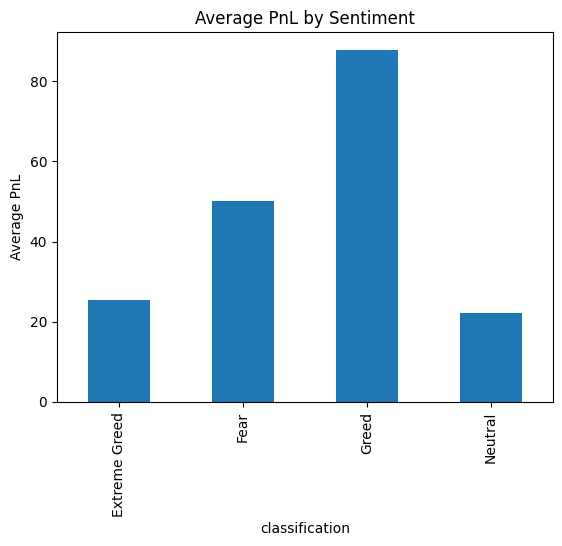

In [43]:
import matplotlib.pyplot as plt
df.groupby('classification')['closed_pnl'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.ylabel("Average PnL")
plt.show()

Do Traders Change Behavior Based on Sentiment?

Trade Frequency

In [44]:
trade_freq = (df.groupby(['classification','date']).size().groupby('classification').mean().reset_index(name='avg_trades_per_day'))
trade_freq

,classification,avg_trades_per_day
0,Extreme Greed,6962.000000
1,Fear,133871.000000
2,Greed,12096.333333
3,Neutral,7141.000000


Average Position Size

In [45]:
position_size = (df.groupby('classification')['size_usd'].mean().reset_index(name='avg_trade_size'))
position_size

,classification,avg_trade_size
0,Extreme Greed,5660.265764
1,Fear,5259.977837
2,Greed,3182.883845
3,Neutral,3058.848110


Long / Short Bias

In [46]:
long_short.groupby('classification')['long_short_ratio'].mean()

,long_short_ratio
classification,
Extreme Greed,0.938736
Fear,0.974790
Greed,0.810548
Neutral,0.963971


Segment 1 - High Exposure vs Low Exposure

In [47]:
median_size = df['size_usd'].median()
df['exposure_type'] = df['size_usd'].apply(lambda x: 'High Exposure' if x > median_size else 'Low Exposure')
segment_perf = (df.groupby(['classification','exposure_type'])['closed_pnl'].mean().reset_index())
segment_perf

,classification,exposure_type,closed_pnl
0,Extreme Greed,High Exposure,39.407556
1,Extreme Greed,Low Exposure,4.018779
2,Fear,High Exposure,95.784210
3,Fear,Low Exposure,3.233227
4,Greed,High Exposure,175.718364
5,Greed,Low Exposure,12.590597
6,Neutral,High Exposure,49.743021
7,Neutral,Low Exposure,1.834576


Segment 2 - Frequent vs Infrequent Traders

In [48]:
trades_per_account = df.groupby('account').size()
threshold = trades_per_account.median()
df['frequency_type'] = df['account'].map(lambda x: 'Frequent' if trades_per_account[x] > threshold else 'Infrequent')
freq_perf = (df.groupby(['classification','frequency_type'])['closed_pnl'].mean().reset_index())
freq_perf

,classification,frequency_type,closed_pnl
0,Extreme Greed,Frequent,26.658319
1,Extreme Greed,Infrequent,-48.382749
2,Fear,Frequent,46.013950
3,Fear,Infrequent,75.639873
4,Greed,Frequent,70.575898
5,Greed,Infrequent,234.886424
6,Neutral,Frequent,4.055615
7,Neutral,Infrequent,356.722004


Segment 3 - Consistent vs Inconsistent Traders

In [49]:
pnl_vol = df.groupby('account')['closed_pnl'].std()
vol_threshold = pnl_vol.median()
df['consistency_type'] = df['account'].map(lambda x: 'Consistent' if pnl_vol[x] < vol_threshold else 'Inconsistent')
consistency_perf = (df.groupby(['classification','consistency_type'])['closed_pnl'].mean().reset_index())
consistency_perf

,classification,consistency_type,closed_pnl
0,Extreme Greed,Consistent,61.769840
1,Extreme Greed,Inconsistent,-2.773933
2,Fear,Consistent,10.402282
3,Fear,Inconsistent,102.956932
4,Greed,Consistent,41.068491
5,Greed,Inconsistent,288.164909
6,Neutral,Consistent,-2.388379
7,Neutral,Inconsistent,50.562763


In [50]:
performance
win_rate_sentiment
segment_perf

,classification,exposure_type,closed_pnl
0,Extreme Greed,High Exposure,39.407556
1,Extreme Greed,Low Exposure,4.018779
2,Fear,High Exposure,95.784210
3,Fear,Low Exposure,3.233227
4,Greed,High Exposure,175.718364
5,Greed,Low Exposure,12.590597
6,Neutral,High Exposure,49.743021
7,Neutral,Low Exposure,1.834576


# Insights

Insight-1

High exposure traders significantly outperform low exposure traders across all sentiment regimes, generating 10–30x higher average PnL. Exposure size appears to be the strongest determinant of profitability.

Insight-2

Greed periods generate the highest average profitability for high exposure traders (avg PnL = 175)

Insight-3

High exposure traders remain profitable during both Fear and Greed regimes, suggesting that volatility rather than sentiment direction alone drives their returns.


In [52]:
segment_perf['pnl_ratio'] = (segment_perf.groupby('classification')['closed_pnl'].transform(lambda x: x / x.min()))

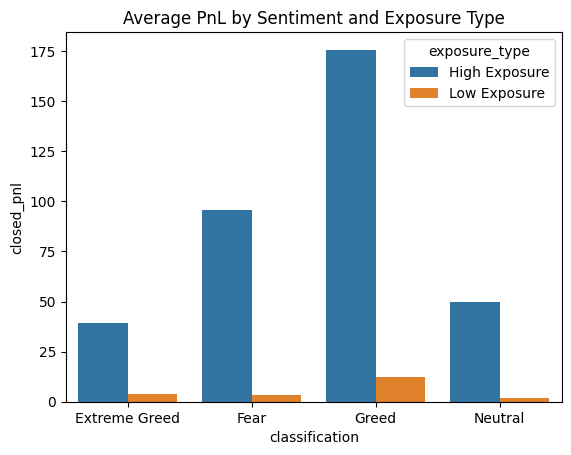

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=segment_perf,x='classification',y='closed_pnl',hue='exposure_type')
plt.title("Average PnL by Sentiment and Exposure Type")
plt.show()

# Part C

Strategy Rule 1 - Dynamic Exposure Scaling

High exposure traders outperform low exposure traders across all sentiment regimes - especially during Greed.


For example:

Greed + High Exposure = 175 avg PnL
Greed + Low Exposure = 12 avg PnL
That’s 14x difference.

During Greed and Extreme Greed regimes, increase position size selectively for historically profitable high exposure traders, while avoiding capital allocation to low exposure accounts.

Strategy Rule 2 - Volatility-Driven Participation Filter

High exposure traders remain profitable even during Fear regimes (95 avg PnL), suggesting volatility benefits active traders.

During Fear regimes, maintain exposure only for high-activity, high-volatility traders, while reducing trade frequency for low-activity accounts to avoid noise-driven losses.

# Bonus

making a predictive model using Kmeans Clustering

Creating Trader-Level Features

In [55]:
trader_features = (df.groupby('account').agg({
          'closed_pnl':'mean',
          'size_usd':'mean',
          'closed_pnl':'std'}).reset_index())
trader_features.columns = ['account','avg_pnl','pnl_volatility']

KMeans Clustering

In [56]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(
    trader_features[['avg_pnl','pnl_volatility']])

In [57]:
kmeans

KMeans(n_clusters=3, random_state=42)

In [58]:
trader_features.head()

,account,avg_pnl,pnl_volatility,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,4692.452329,16159.576734,2
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,134.073473,1653.226327,1
2,0x271b280974205ca63b716753467d5a371de622ab,542.182659,8893.000898,0
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,113.269353,507.626933,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,255.829091,3138.894782,1


above table shows Average pnl, Pnl Volatility and presence in clusters

now Examining Cluster Statistics

In [59]:
cluster_summary = (trader_features.groupby('cluster').agg({
        'avg_pnl':'mean',
        'pnl_volatility':'mean',
        'account':'count'}).rename(columns={'account':'num_traders'}))
cluster_summary

,avg_pnl,pnl_volatility,num_traders
cluster,,,
0,1185.094287,7549.289766,7
1,608.452408,2345.229884,21
2,1580.157952,22539.720976,4


Visualizing Clusters using scatter plot


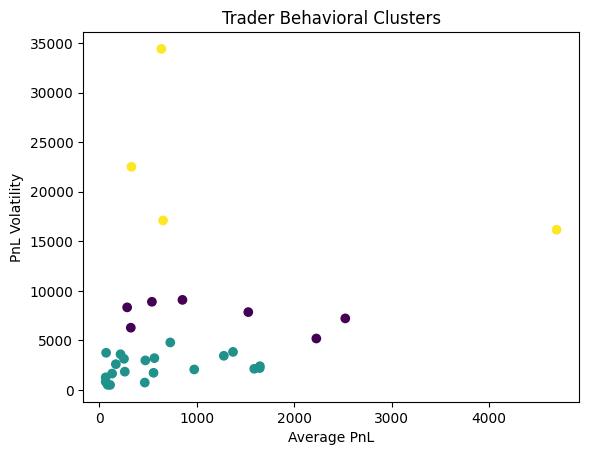

In [60]:
import matplotlib.pyplot as plt
plt.scatter(trader_features['avg_pnl'],trader_features['pnl_volatility'],c=trader_features['cluster'])
plt.xlabel("Average PnL")
plt.ylabel("PnL Volatility")
plt.title("Trader Behavioral Clusters")
plt.show()

In [63]:
cluster_summary

,avg_pnl,pnl_volatility,num_traders
cluster,,,
0,1185.094287,7549.289766,7
1,608.452408,2345.229884,21
2,1580.157952,22539.720976,4


Connecting Clusters to Sentiment

In [61]:
df = df.merge(trader_features[['account','cluster']],on='account',how='left')

checking performance by cluster + sentiment

In [62]:
cluster_sentiment = (df.groupby(['classification','cluster'])['closed_pnl'].mean().reset_index())
cluster_sentiment

,classification,cluster,closed_pnl
0,Extreme Greed,1,29.667035
1,Extreme Greed,2,-10.848590
2,Fear,0,125.269629
3,Fear,1,26.405582
4,Fear,2,145.566650
5,Greed,0,422.481121
6,Greed,1,90.779242
7,Greed,2,-90.567589
8,Neutral,0,-0.200000
9,Neutral,1,31.703258


Behavioral Archetypes (Clustering)


Three distinct trader archetypes were identified:

1.Aggressive Winners – High return, high volatility traders benefiting most during Greed regimes.

2.Passive Traders – Low risk, low reward traders with minimal sentiment sensitivity.

3.Risky Underperformers – High volatility traders with negative expectancy, particularly vulnerable during Fear regimes.

Performance analysis shows sentiment amplifies outcomes for high-volatility traders, particularly during Greed regimes.